In [73]:
# ============================================================
# Assignment No. 2 – Generative AI (AI4009) Spring 2026
# Self-Supervised Image Representation Learning using MAE
# National University of Computer and Emerging Sciences
# ============================================================
# Platform   : Kaggle Notebook
# Accelerator: GPU T4 x1 or x2
# ============================================================


# ─────────────────────────────────────────
# CELL 1 – Install dependencies
# ─────────────────────────────────────────
!pip install -q einops gradio scikit-image



In [74]:
# ─────────────────────────────────────────
# CELL 2 – Imports & Device Setup
# ─────────────────────────────────────────
import os, math, random, time, shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torch.cuda.amp import GradScaler, autocast

from einops import rearrange, repeat
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

NUM_GPUS = torch.cuda.device_count()
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPUs available : {NUM_GPUS}")
print(f"Primary device : {DEVICE}")
for i in range(NUM_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name}  ({props.total_memory // 1024**3} GB)")

OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

GPUs available : 2
Primary device : cuda
  GPU 0: Tesla T4  (14 GB)
  GPU 1: Tesla T4  (14 GB)


In [75]:
# ─────────────────────────────────────────
# CELL 3 – Configuration
# ─────────────────────────────────────────
class Config:

    # Data
    DATA_DIR    = ""
    IMAGE_SIZE  = 64
    PATCH_SIZE  = 8
    MASK_RATIO  = 0.75
    NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 64

    # Encoder – ViT-Small
    ENC_DIM       = 384
    ENC_DEPTH     = 8
    ENC_HEADS     = 6
    ENC_MLP_RATIO = 4.0

    # Decoder – Lightweight
    DEC_DIM       = 192
    DEC_DEPTH     = 4
    DEC_HEADS     = 3
    DEC_MLP_RATIO = 4.0

    # Training
    EPOCHS        = 3
    BATCH_SIZE    = 128
    LR            = 2e-4
    WEIGHT_DECAY  = 0.05
    WARMUP_EPOCHS = 1
    GRAD_CLIP     = 1.0
    NUM_WORKERS   = 4


cfg = Config()

print(f"Image  : {cfg.IMAGE_SIZE}×{cfg.IMAGE_SIZE}  |  "
      f"Patch  : {cfg.PATCH_SIZE}×{cfg.PATCH_SIZE}  |  "
      f"Patches: {cfg.NUM_PATCHES}  |  "
      f"Visible: {int(cfg.NUM_PATCHES*(1-cfg.MASK_RATIO))}  |  "
      f"Batch  : {cfg.BATCH_SIZE}")

Image  : 64×64  |  Patch  : 8×8  |  Patches: 64  |  Visible: 16  |  Batch  : 128


In [76]:
import shutil, os

val_path = "/kaggle/working/val"

if os.path.exists(val_path):
    shutil.rmtree(val_path)

print("Old validation folder removed.")

Old validation folder removed.


In [77]:
# ─────────────────────────────────────────
# CELL 4 – Dataset Setup
# train/ is used directly from the read-only kagglehub cache (no copy needed).
# Only val/ is copied to /kaggle/working/ so we can reorganise it (~10k images, fast).
# ─────────────────────────────────────────
import kagglehub

def find_train_dir(base):
    """Walk up to 2 levels to find the folder containing train/ and val/."""
    if os.path.isdir(os.path.join(base, "train")):
        return base
    for entry in sorted(os.listdir(base)):
        candidate = os.path.join(base, entry)
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "train")):
            return candidate
    raise FileNotFoundError(
        f"Could not find train/ inside {base}\n"
        f"Contents: {os.listdir(base)}"
    )

def prepare_val_dir(val_dst):

    ann_file = os.path.join(val_dst, "val_annotations.txt")
    img_dir  = os.path.join(val_dst, "images")

    if not os.path.exists(ann_file):
        raise FileNotFoundError("val_annotations.txt not found")

    moved = 0

    with open(ann_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            img_name = parts[0]
            class_id = parts[1]

            class_dir = os.path.join(val_dst, class_id)
            os.makedirs(class_dir, exist_ok=True)

            src = os.path.join(img_dir, img_name)
            dst = os.path.join(class_dir, img_name)

            if os.path.exists(src):
                shutil.move(src, dst)
                moved += 1

    print(f"Moved {moved} validation images")

    # remove images folder
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)
        
# Step 1 – download / locate dataset (uses local cache, near-instant)
_raw_path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
_src      = find_train_dir(_raw_path)
print("Read-only source:", _src)

# Step 2 – train/ is read-only but ImageFolder only reads it → use directly
TRAIN_DIR = os.path.join(_src, "train")
print("Train dir       :", TRAIN_DIR)

# Copy validation dataset
VAL_DST = "/kaggle/working/val"

print("Copying validation dataset...")
shutil.copytree(os.path.join(_src, "val"), VAL_DST)

print("Organizing validation images...")
prepare_val_dir(VAL_DST)

cfg.TRAIN_DIR = TRAIN_DIR
cfg.VAL_DIR   = VAL_DST

print("Dataset ready")

Read-only source: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
Train dir       : /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train
Copying validation dataset...
Organizing validation images...
Moved 10000 validation images
Dataset ready


In [78]:
print("Example val folders:")
print(os.listdir(cfg.VAL_DIR)[:10])

Example val folders:
['n02795169', 'n04371430', 'n03937543', 'n04251144', 'n03637318', 'n02321529', 'n03255030', 'n02085620', 'n04487081', 'n02999410']


In [79]:
# ─────────────────────────────────────────
# CELL 5 – DataLoaders
# ─────────────────────────────────────────
mean = [0.4802, 0.4481, 0.3975]
std  = [0.2302, 0.2265, 0.2262]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMAGE_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_tf = transforms.Compose([
    transforms.Resize(cfg.IMAGE_SIZE),
    transforms.CenterCrop(cfg.IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Ensure val folder is properly organised
if "images" in os.listdir(cfg.VAL_DIR): 
    print("Reorganizing validation folder...")
    prepare_val_dir(cfg.VAL_DIR)
    
train_dataset = datasets.ImageFolder(cfg.TRAIN_DIR, transform=train_tf)
val_dataset = datasets.ImageFolder(cfg.VAL_DIR, transform=val_tf, is_valid_file=lambda x: x.lower().endswith((".jpeg", ".jpg", ".png"))
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

In [80]:
# ─────────────────────────────────────────
# CELL 6 – Building Blocks
# ─────────────────────────────────────────
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1,2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))

class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop),
        )
    def forward(self, x): return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = Attention(dim, num_heads, attn_drop, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


In [81]:
# ─────────────────────────────────────────
# CELL 7 – MAE Encoder (ViT-Base)
# ─────────────────────────────────────────
class MAEEncoder(nn.Module):
    """Processes ONLY the visible (unmasked) 25% of patches."""
    def __init__(self, img_size=64, patch_size=8, in_chans=3,
                 embed_dim=768, depth=12, num_heads=12,
                 mlp_ratio=4.0, mask_ratio=0.75):
        super().__init__()
        self.patch_size  = patch_size
        self.mask_ratio  = mask_ratio
        self.num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Linear(in_chans * patch_size * patch_size, embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def patchify(self, imgs):
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p).permute(0,2,4,1,3,5)
        return x.reshape(B, h*w, C*p*p)

    def random_masking(self, x):
        B, N, D = x.shape
        keep_n       = int(N * (1 - self.mask_ratio))
        noise        = torch.rand(B, N, device=x.device)
        ids_shuffle  = torch.argsort(noise, dim=1)
        ids_restore  = torch.argsort(ids_shuffle, dim=1)
        ids_keep     = ids_shuffle[:, :keep_n]
        x_visible    = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1,-1,D))
        mask = torch.ones(B, N, device=x.device)
        mask.scatter_(1, ids_keep, 0.)
        return x_visible, mask, ids_restore

    def forward(self, imgs):
        x = self.patch_embed(self.patchify(imgs))
        x = x + self.pos_embed[:, 1:, :]
        x, mask, ids_restore = self.random_masking(x)
        cls = (self.cls_token + self.pos_embed[:, :1, :]).expand(x.shape[0], -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.norm(self.blocks(x))
        return x, mask, ids_restore



In [82]:
# ─────────────────────────────────────────
# CELL 8 – MAE Decoder (ViT-Small)
# ─────────────────────────────────────────
class MAEDecoder(nn.Module):
    """Reconstructs ALL patches using visible tokens + learnable mask tokens."""
    def __init__(self, num_patches, patch_size=8, in_chans=3,
                 encoder_embed_dim=768, decoder_embed_dim=384,
                 depth=6, num_heads=6, mlp_ratio=4.0):
        super().__init__()
        patch_dim = in_chans * patch_size * patch_size
        self.num_patches        = num_patches
        self.encoder_to_decoder = nn.Linear(encoder_embed_dim, decoder_embed_dim, bias=True)
        self.mask_token         = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.pos_embed          = nn.Parameter(torch.zeros(1, num_patches+1, decoder_embed_dim))
        self.blocks = nn.Sequential(*[
            TransformerBlock(decoder_embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_embed_dim)
        self.head = nn.Linear(decoder_embed_dim, patch_dim, bias=True)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x_enc, ids_restore):
        x        = self.encoder_to_decoder(x_enc)
        keep_n   = x.shape[1] - 1
        mask_n   = self.num_patches - keep_n
        mask_tok = self.mask_token.expand(x.shape[0], mask_n, -1)
        full     = torch.cat([x[:, 1:, :], mask_tok], dim=1)
        full     = torch.gather(full, 1, ids_restore.unsqueeze(-1).expand(-1,-1,x.shape[-1]))
        full     = full + self.pos_embed[:, 1:, :]
        cls      = x[:, :1, :] + self.pos_embed[:, :1, :]
        full     = torch.cat([cls, full], dim=1)
        full     = self.norm(self.blocks(full))
        return self.head(full[:, 1:, :])



In [83]:
# ─────────────────────────────────────────
# CELL 9 – Full MAE Model
# ─────────────────────────────────────────
class MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = MAEEncoder(
            img_size=cfg.IMAGE_SIZE, patch_size=cfg.PATCH_SIZE,
            embed_dim=cfg.ENC_DIM, depth=cfg.ENC_DEPTH,
            num_heads=cfg.ENC_HEADS, mlp_ratio=cfg.ENC_MLP_RATIO,
            mask_ratio=cfg.MASK_RATIO,
        )
        self.decoder = MAEDecoder(
            num_patches=cfg.NUM_PATCHES, patch_size=cfg.PATCH_SIZE,
            encoder_embed_dim=cfg.ENC_DIM, decoder_embed_dim=cfg.DEC_DIM,
            depth=cfg.DEC_DEPTH, num_heads=cfg.DEC_HEADS,
            mlp_ratio=cfg.DEC_MLP_RATIO,
        )
        self.patch_size = cfg.PATCH_SIZE
        self.image_size = cfg.IMAGE_SIZE

    def forward(self, imgs):
        latent, mask, ids_restore = self.encoder(imgs)
        pred = self.decoder(latent, ids_restore)
        loss = self.compute_loss(imgs, pred, mask)
        return loss, pred, mask

    def compute_loss(self, imgs, pred, mask):
        target = self.encoder.patchify(imgs)
        loss   = (pred - target) ** 2
        loss   = loss.mean(dim=-1)
        return (loss * mask).sum() / mask.sum()

    def unpatchify(self, x):
        p = self.patch_size
        h = w = self.image_size // p
        x = x.reshape(x.shape[0], h, w, 3, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5)
        return x.reshape(x.shape[0], 3, h*p, w*p)

# Build model – wrap in DataParallel if dual GPU is available
_model = MAE(cfg).to(DEVICE)
model  = nn.DataParallel(_model) if NUM_GPUS > 1 else _model
if NUM_GPUS > 1:
    print(f"✅  DataParallel across {NUM_GPUS} GPUs")

def unwrap(m):
    """Return underlying model, stripping DataParallel wrapper if present."""
    return m.module if isinstance(m, nn.DataParallel) else m

enc_p = sum(p.numel() for p in unwrap(model).encoder.parameters()) / 1e6
dec_p = sum(p.numel() for p in unwrap(model).decoder.parameters()) / 1e6
print(f"Encoder: {enc_p:.1f}M  |  Decoder: {dec_p:.1f}M  |  Total: {enc_p+dec_p:.1f}M params")


✅  DataParallel across 2 GPUs
Encoder: 14.3M  |  Decoder: 1.9M  |  Total: 16.2M params


In [84]:
# ─────────────────────────────────────────
# CELL 10 – Optimizer & LR Scheduler
# ─────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.LR,
    betas=(0.9, 0.95), weight_decay=cfg.WEIGHT_DECAY,
)

def cosine_lr(optimizer, epoch, warmup_epochs, total_epochs, base_lr, min_lr=1e-6):
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs
    else:
        prog = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        lr   = min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * prog))
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr

scaler = torch.amp.GradScaler("cuda")

In [85]:
# ─────────────────────────────────────────
# CELL 11 – Train & Validate Functions
# ─────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    total = 0.
    for i, (imgs, _) in enumerate(loader):
        imgs = imgs.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            loss, _, _ = model(imgs)
            loss = loss.mean() if loss.numel() > 1 else loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total += loss.item()
        if i % 200 == 0:
            print(f"  [Epoch {epoch+1}] Step {i:4d}/{len(loader)}  loss={loss.item():.4f}")
    return total / len(loader)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total = 0.
    for imgs, _ in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast():
            loss, _, _ = model(imgs)
            loss = loss.mean() if loss.numel() > 1 else loss
        total += loss.item()
    return total / len(loader)



In [86]:
# ─────────────────────────────────────────
# CELL 12 – Training Loop
# ─────────────────────────────────────────
train_losses, val_losses, lr_history = [], [], []
best_val_loss = float("inf")
ckpt_path     = os.path.join(OUT_DIR, "best_mae.pth")

print("=" * 55)
print(f"  Training MAE  –  {cfg.EPOCHS} epochs  –  {NUM_GPUS} GPU(s)")
print("=" * 55)

for epoch in range(cfg.EPOCHS):
    t0 = time.time()
    lr = cosine_lr(optimizer, epoch, cfg.WARMUP_EPOCHS, cfg.EPOCHS, cfg.LR)
    lr_history.append(lr)

    tr  = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
    val = validate(model, val_loader)
    train_losses.append(tr); val_losses.append(val)

    print(f"Epoch [{epoch+1}/{cfg.EPOCHS}]  "
          f"Train: {tr:.4f}  Val: {val:.4f}  "
          f"LR: {lr:.2e}  Time: {time.time()-t0:.1f}s")

    if val < best_val_loss:
        best_val_loss = val
        torch.save(unwrap(model).state_dict(), ckpt_path)
        print(f"  ✅ Checkpoint saved")

print(f"\nDone.  Best Val Loss: {best_val_loss:.4f}")


  Training MAE  –  3 epochs  –  2 GPU(s)


/tmp/ipykernel_55/867413815.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  [Epoch 1] Step    0/781  loss=1.6453
  [Epoch 1] Step  200/781  loss=0.8316
  [Epoch 1] Step  400/781  loss=0.7800
  [Epoch 1] Step  600/781  loss=0.8423


/tmp/ipykernel_55/867413815.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/3]  Train: 0.8649  Val: 0.9579  LR: 2.00e-04  Time: 115.1s
  ✅ Checkpoint saved
  [Epoch 2] Step    0/781  loss=0.8173
  [Epoch 2] Step  200/781  loss=0.8096
  [Epoch 2] Step  400/781  loss=0.7515
  [Epoch 2] Step  600/781  loss=0.7864
Epoch [2/3]  Train: 0.7216  Val: 0.8782  LR: 2.00e-04  Time: 113.9s
  ✅ Checkpoint saved
  [Epoch 3] Step    0/781  loss=0.7547
  [Epoch 3] Step  200/781  loss=0.7072
  [Epoch 3] Step  400/781  loss=0.6596
  [Epoch 3] Step  600/781  loss=0.6151
Epoch [3/3]  Train: 0.6538  Val: 0.7977  LR: 1.01e-04  Time: 113.4s
  ✅ Checkpoint saved

Done.  Best Val Loss: 0.7977


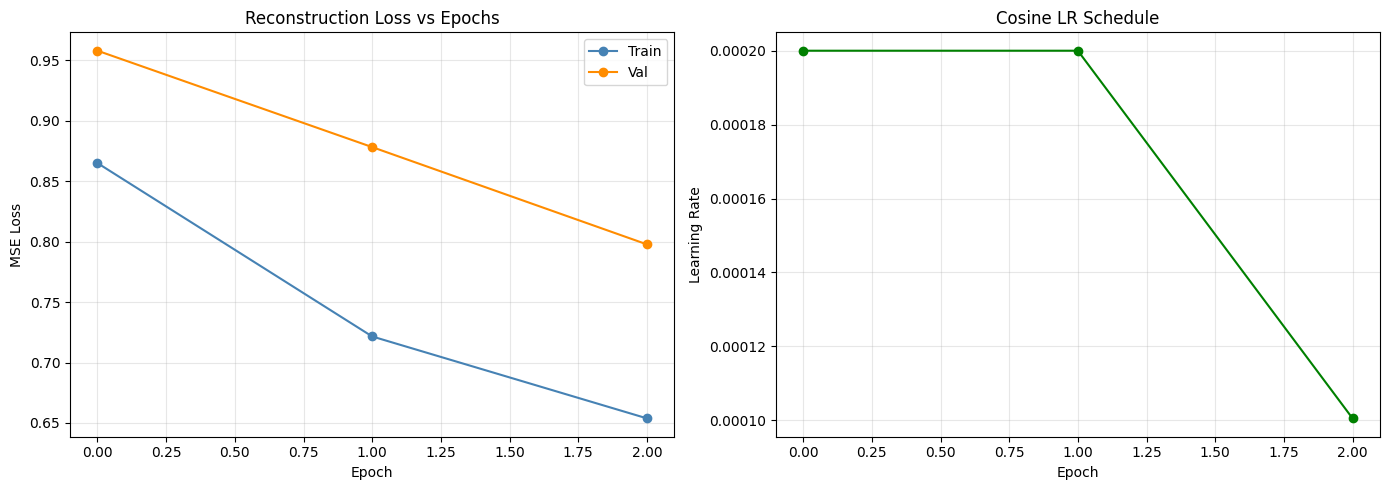

In [87]:
# ─────────────────────────────────────────
# CELL 13 – Training Curves
# ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train", color="steelblue",  marker="o")
ax1.plot(val_losses,   label="Val",   color="darkorange", marker="o")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Reconstruction Loss vs Epochs")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(lr_history, color="green", marker="o")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_title("Cosine LR Schedule")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
plt.show()


/tmp/ipykernel_55/2986338998.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


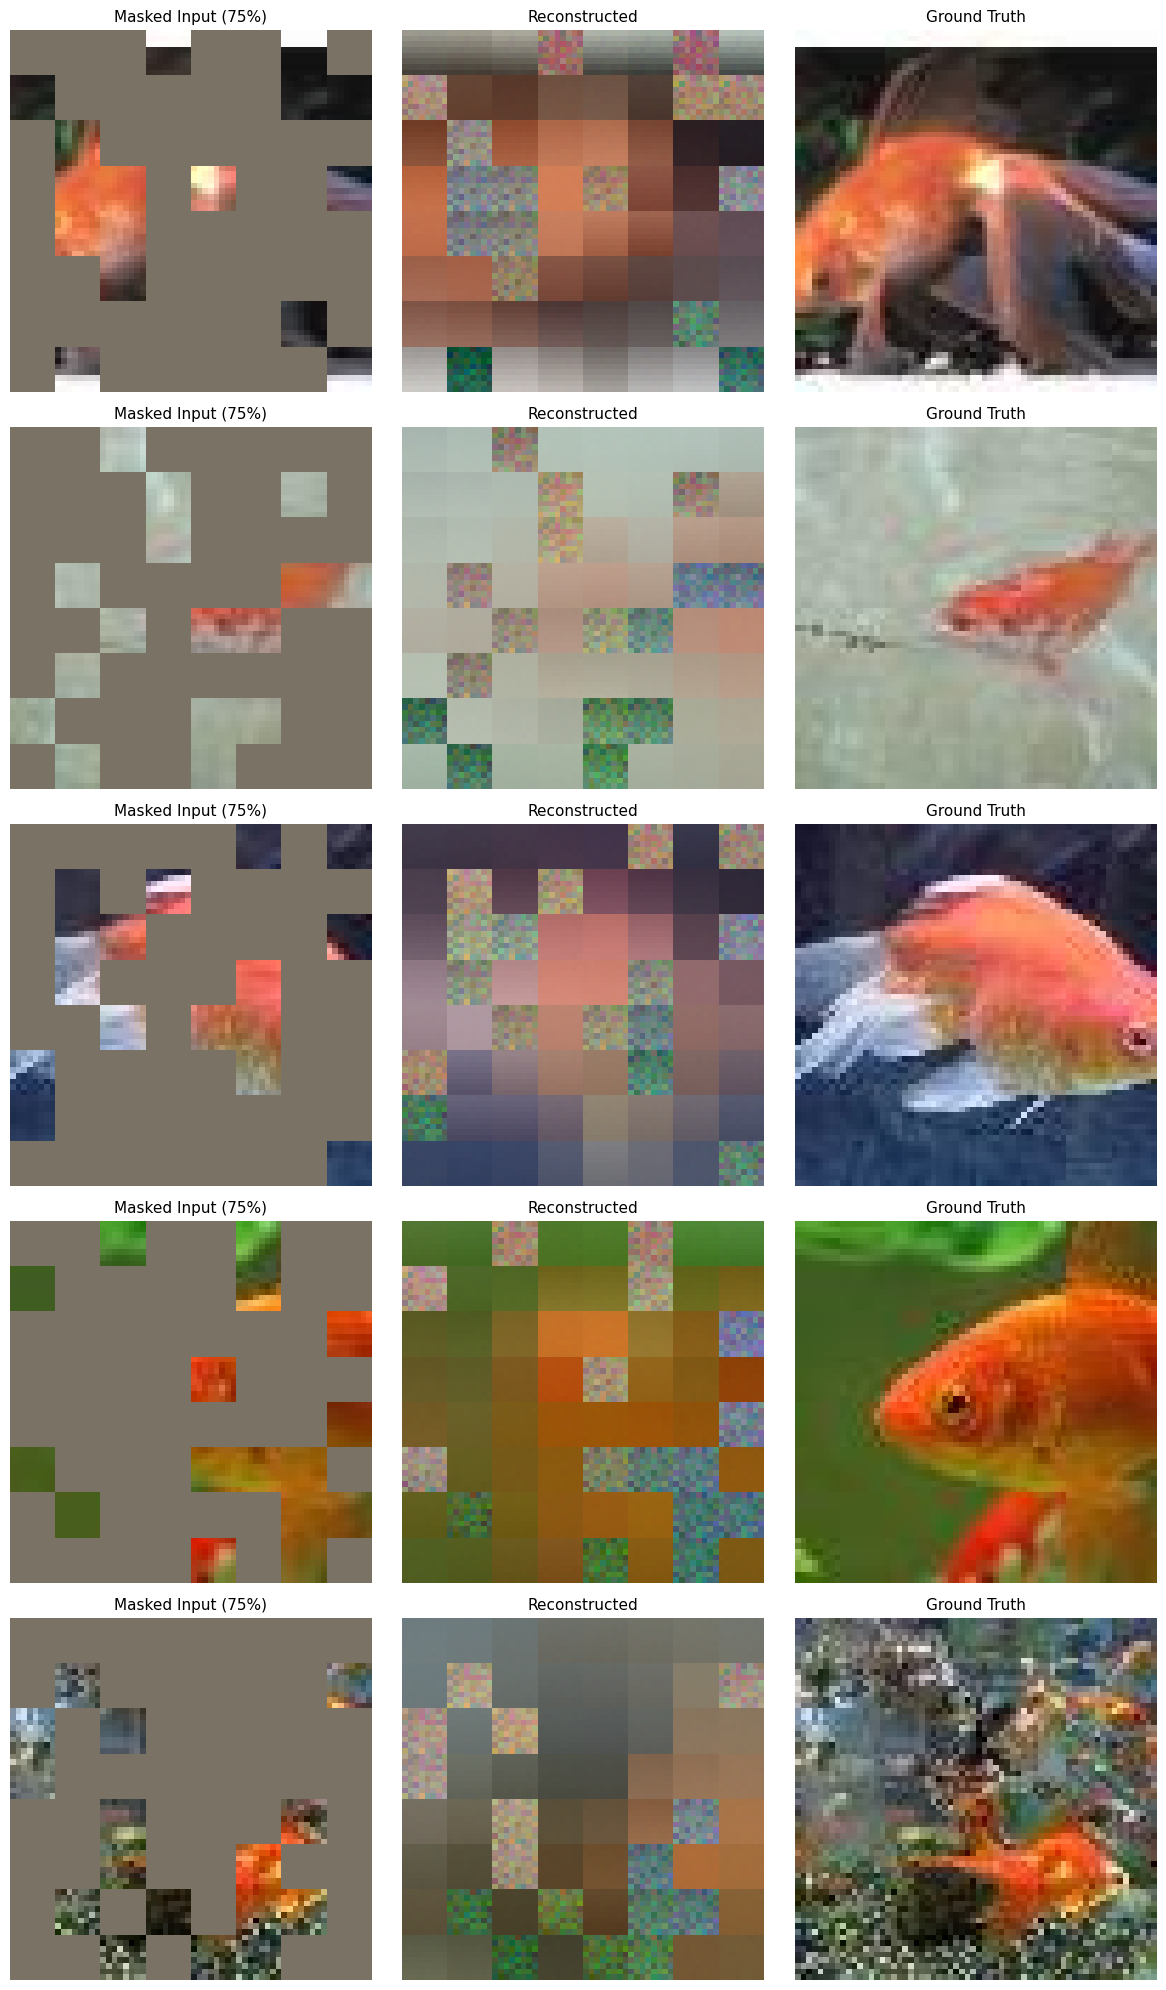

✅  Saved reconstruction_samples.png


In [88]:
# ─────────────────────────────────────────
# CELL 14 – Qualitative Visualisation (5 samples)
# ─────────────────────────────────────────
def denormalize(t):
    m = torch.tensor(mean).view(3,1,1).to(t.device)
    s = torch.tensor(std).view(3,1,1).to(t.device)
    return ((t * s + m).clamp(0,1).permute(1,2,0).cpu().numpy())

def visualise(model, loader, n=5):
    raw = unwrap(model); raw.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)

    with torch.no_grad(), autocast():
        _, pred, mask = raw(imgs)

    pred_imgs = raw.unpatchify(pred)
    patches   = raw.encoder.patchify(imgs)
    me        = mask.unsqueeze(-1).expand_as(patches)
    mp        = patches.clone(); mp[me == 1] = 0.
    masked    = raw.unpatchify(mp)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    for i in range(n):
        for j, (title, src) in enumerate(zip(
            ["Masked Input (75%)", "Reconstructed", "Ground Truth"],
            [masked, pred_imgs, imgs]
        )):
            axes[i,j].imshow(denormalize(src[i]))
            axes[i,j].set_title(title, fontsize=11)
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "reconstruction_samples.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("✅  Saved reconstruction_samples.png")

unwrap(model).load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
visualise(model, val_loader)

/tmp/ipykernel_55/4056619339.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  Samples  : 1280
  Mean PSNR: 13.45 dB
  Mean SSIM: 0.1137


/tmp/ipykernel_55/4056619339.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


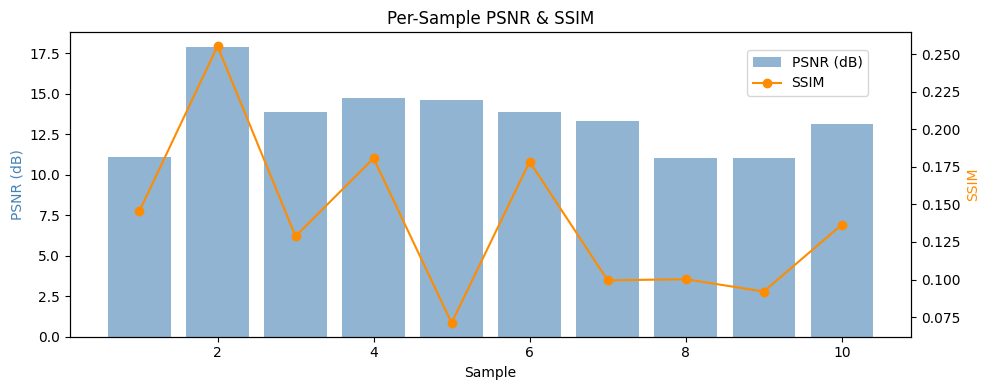

In [89]:
# ─────────────────────────────────────────
# CELL 15 – Quantitative Metrics (PSNR & SSIM)
# ─────────────────────────────────────────
@torch.no_grad()
def compute_metrics(model, loader, num_batches=10):
    raw = unwrap(model); raw.eval()
    psnrs, ssims = [], []
    for i, (imgs, _) in enumerate(loader):
        if i >= num_batches: break
        imgs = imgs.to(DEVICE)
        with autocast():
            _, pred, _ = raw(imgs)
        pred_imgs = raw.unpatchify(pred)
        for j in range(imgs.shape[0]):
            orig  = denormalize(imgs[j])
            recon = denormalize(pred_imgs[j])
            psnrs.append(psnr_fn(orig, recon, data_range=1.0))
            ssims.append(ssim_fn(orig, recon, data_range=1.0, channel_axis=-1))
    print(f"\n{'='*45}")
    print(f"  Samples  : {len(psnrs)}")
    print(f"  Mean PSNR: {np.mean(psnrs):.2f} dB")
    print(f"  Mean SSIM: {np.mean(ssims):.4f}")
    print(f"{'='*45}")
    return np.mean(psnrs), np.mean(ssims)

psnr_val, ssim_val = compute_metrics(model, val_loader)

@torch.no_grad()
def plot_metrics(model, loader, n=10):
    raw = unwrap(model); raw.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    with autocast():
        _, pred, _ = raw(imgs)
    pred_imgs = raw.unpatchify(pred)
    psnrs = [psnr_fn(denormalize(imgs[i]), denormalize(pred_imgs[i]), data_range=1.0) for i in range(n)]
    ssims = [ssim_fn(denormalize(imgs[i]), denormalize(pred_imgs[i]), data_range=1.0, channel_axis=-1) for i in range(n)]

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(range(1,n+1), psnrs, alpha=0.6, color="steelblue", label="PSNR (dB)")
    ax1.set_xlabel("Sample"); ax1.set_ylabel("PSNR (dB)", color="steelblue")
    ax2 = ax1.twinx()
    ax2.plot(range(1,n+1), ssims, "o-", color="darkorange", label="SSIM")
    ax2.set_ylabel("SSIM", color="darkorange")
    ax1.set_title("Per-Sample PSNR & SSIM")
    fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "per_sample_metrics.png"), dpi=150)
    plt.show()

plot_metrics(model, val_loader)


In [92]:
# ─────────────────────────────────────────
# CELL 16 – Gradio App
# ─────────────────────────────────────────
import gradio as gr

def mae_inference(pil_img, mask_ratio: float):
    raw = unwrap(model)
    old = raw.encoder.mask_ratio
    raw.encoder.mask_ratio = mask_ratio

    tf = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    img_t = tf(pil_img.convert("RGB")).unsqueeze(0).to(DEVICE)

    raw.eval()
    with torch.no_grad():
        _, pred, mask = raw(img_t)

    pred_img = raw.unpatchify(pred)
    patches  = raw.encoder.patchify(img_t)
    me       = mask.unsqueeze(-1).expand_as(patches)
    mp       = patches.clone(); mp[me == 1] = 0.
    masked   = raw.unpatchify(mp)

    raw.encoder.mask_ratio = old
    u8 = lambda x: (denormalize(x) * 255).astype(np.uint8)
    return u8(masked[0]), u8(pred_img[0]), u8(img_t[0])

with gr.Blocks(title="MAE Demo") as demo:
    gr.Markdown("## Masked Autoencoder – Image Reconstruction Demo")
    gr.Markdown("Upload an image, choose a masking ratio, and see the reconstruction.")
    with gr.Row():
        inp = gr.Image(type="pil", label="Upload Image")
        sl  = gr.Slider(0.1, 0.9, value=0.75, step=0.05, label="Masking Ratio")
    btn = gr.Button("Run Reconstruction", variant="primary")
    with gr.Row():
        o1 = gr.Image(label="Masked Input")
        o2 = gr.Image(label="Reconstruction")
        o3 = gr.Image(label="Original")
    btn.click(fn=mae_inference, inputs=[inp, sl], outputs=[o1, o2, o3])

demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7862

Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


In [98]:
!mkdir -p /root/.cache/huggingface/gradio/frpc

In [99]:
!mv /kaggle/working/frpc_linux_amd64 /root/.cache/huggingface/gradio/frpc/

mv: cannot stat '/kaggle/working/frpc_linux_amd64': No such file or directory
